# 🔤 Notebook 1: Character-Level Tokenization

**Based on Lecture 7 from Vizuara AI Series**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand **why tokenization is necessary**
2. Build a **character-level tokenizer** from scratch
3. Implement **encode** and **decode** functions
4. Analyze **trade-offs** (vocab size vs sequence length)
5. Convert text to **PyTorch tensors**

---

## 📚 Table of Contents

1. [Why Tokenization?](#1-why-tokenization)
2. [Loading the Dataset](#2-loading-the-dataset)
3. [Building the Vocabulary](#3-building-the-vocabulary)
4. [Creating Mappings (stoi/itos)](#4-creating-mappings)
5. [Encode and Decode Functions](#5-encode-and-decode-functions)
6. [Converting to Tensors](#6-converting-to-tensors)
7. [Trade-offs Analysis](#7-trade-offs-analysis)
8. [Key Takeaways](#8-key-takeaways)

In [23]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
import pickle
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ Libraries imported successfully!
PyTorch version: 2.10.0+cpu


### 🌐 Environment Setup (Colab/Local)

This cell detects whether you're running in Google Colab or locally and sets up the environment accordingly.

In [24]:
# ========================================
# ENVIRONMENT DETECTION & SETUP
# ========================================

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("🌐 Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

# Setup directories
if IN_COLAB:
    # Create necessary directories for Colab
    os.makedirs('data', exist_ok=True)
    os.makedirs('visualizations/tokenization', exist_ok=True)
    print("✅ Created directories: data/, visualizations/tokenization/")
    
    # Set paths for Colab
    DATA_DIR = 'data'
    VIZ_DIR = 'visualizations/tokenization'
else:
    # Use relative paths for local execution
    DATA_DIR = '../data'
    VIZ_DIR = '../visualizations/tokenization'
    
    # Check if directories exist
    if not os.path.exists(DATA_DIR):
        print(f"⚠️ Warning: {DATA_DIR} directory not found")
    if not os.path.exists(VIZ_DIR):
        os.makedirs(VIZ_DIR, exist_ok=True)
        print(f"✅ Created {VIZ_DIR} directory")

print(f"\n📁 Data directory: {DATA_DIR}")
print(f"📊 Visualization directory: {VIZ_DIR}")

🌐 Running in Google Colab
✅ Created directories: data/, visualizations/tokenization/

📁 Data directory: data
📊 Visualization directory: visualizations/tokenization


### 📥 Get Sample Data

This cell automatically downloads sample text data (Shakespeare) for training.

In [25]:
# ========================================
# DATA ACQUISITION
# ========================================

sample_path = f'{DATA_DIR}/sample.txt'

# Check if data already exists
if os.path.exists(sample_path):
    print(f"✅ Data file already exists: {sample_path}")
else:
    if IN_COLAB:
        # Download sample data automatically in Colab
        import urllib.request
        
        print("📥 Downloading sample data (Shakespeare text)...")
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        
        try:
            urllib.request.urlretrieve(url, sample_path)
            print(f"✅ Downloaded successfully to {sample_path}")
        except Exception as e:
            print(f"❌ Error downloading file: {e}")
            print("\n💡 Alternative: You can manually upload a text file using:")
            print("   from google.colab import files")
            print("   uploaded = files.upload()")
    else:
        print(f"❌ Error: {sample_path} not found!")
        print(f"\n💡 Please create the file at: {sample_path}")
        print(f"   You can download it from:")
        print(f"   https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt")

# Verify and show stats
if os.path.exists(sample_path):
    with open(sample_path, 'r', encoding='utf-8') as f:
        text_preview = f.read()
    
    print(f"\n📊 File Statistics:")
    print(f"   Total characters: {len(text_preview):,}")
    print(f"   Total lines: {len(text_preview.splitlines()):,}")
    print(f"\n📝 First 200 characters:")
    print(f"   {text_preview[:200]}...")
    print(f"\n✅ Data ready for processing!")

✅ Data file already exists: data/sample.txt

📊 File Statistics:
   Total characters: 1,115,394
   Total lines: 40,000

📝 First 200 characters:
   First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you...

✅ Data ready for processing!


---

## 1. Why Tokenization?

### 🧠 The Problem

Neural networks work with **numbers**, not text. We need to convert:

```
"Hello World" → [72, 101, 108, 108, 111, 32, 87, 111, 114, 108, 100]
```

### 🔍 What is a Token?

A **token** is the basic unit of text that the model processes. It could be:

- **Character**: 'H', 'e', 'l', 'l', 'o'
- **Sub-word**: 'Hel', 'lo', 'Wor', 'ld'
- **Word**: 'Hello', 'World'

### 📊 Tokenization Approaches

| Method | Vocab Size | Sequence Length | Pros | Cons |
|--------|-----------|----------------|------|------|
| **Character** | ~65-100 | Very Long | Simple, no unknowns | Long sequences |
| **Sub-word (BPE)** | ~50K | Moderate | Balanced | Complex algorithm |
| **Word** | ~100K+ | Short | Intuitive | Many unknowns |

**In this notebook, we'll implement character-level tokenization** because it's the simplest to understand.

---

## 2. Loading the Dataset

We'll use a sample of Shakespeare's text for this tutorial.

In [26]:
# Load the dataset (using environment-specific path)
data_file = f'{DATA_DIR}/sample.txt'
with open(data_file, 'r', encoding='utf-8') as f:
    text = f.read()

# Display statistics
print("📊 Dataset Statistics:")
print(f"Total characters: {len(text):,}")
print(f"Total lines: {len(text.splitlines())}")
print(f"\n📝 First 500 characters:")
print("-" * 80)
print(text[:500])
print("-" * 80)

📊 Dataset Statistics:
Total characters: 1,115,394
Total lines: 40000

📝 First 500 characters:
--------------------------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
--------------------------------------------------------------------------------


---

## 3. Building the Vocabulary

### 🎯 Goal

Find all **unique characters** in the text. This becomes our vocabulary.

### 💻 Implementation

In [ ]:
# Extract unique characters
# set(text) — converts the text string into a set, which automatically removes duplicates, leaving only unique characters
# list(...) — converts the set into a list (since sets are unordered and can't be sorted directly)
# sorted(...) — sorts the list alphabetically/by ASCII value, giving a consistent ordering
chars = sorted(list(set(text)))
vocab_size = len(chars)

print(f"🔤 Vocabulary Size: {vocab_size}")
print(f"\n📋 All characters in vocabulary:")
print(''.join(chars))
print(f"\n🔍 Character breakdown:")
print(f"Letters: {sum(1 for c in chars if c.isalpha())}")
print(f"Digits: {sum(1 for c in chars if c.isdigit())}")
print(f"Punctuation: {sum(1 for c in chars if not c.isalnum() and not c.isspace())}")
print(f"Whitespace: {sum(1 for c in chars if c.isspace())}")

🔤 Vocabulary Size: 65

📋 All characters in vocabulary:

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

🔍 Character breakdown:
Letters: 52
Digits: 1
Punctuation: 10
Whitespace: 2


### 📊 Character Frequency Analysis

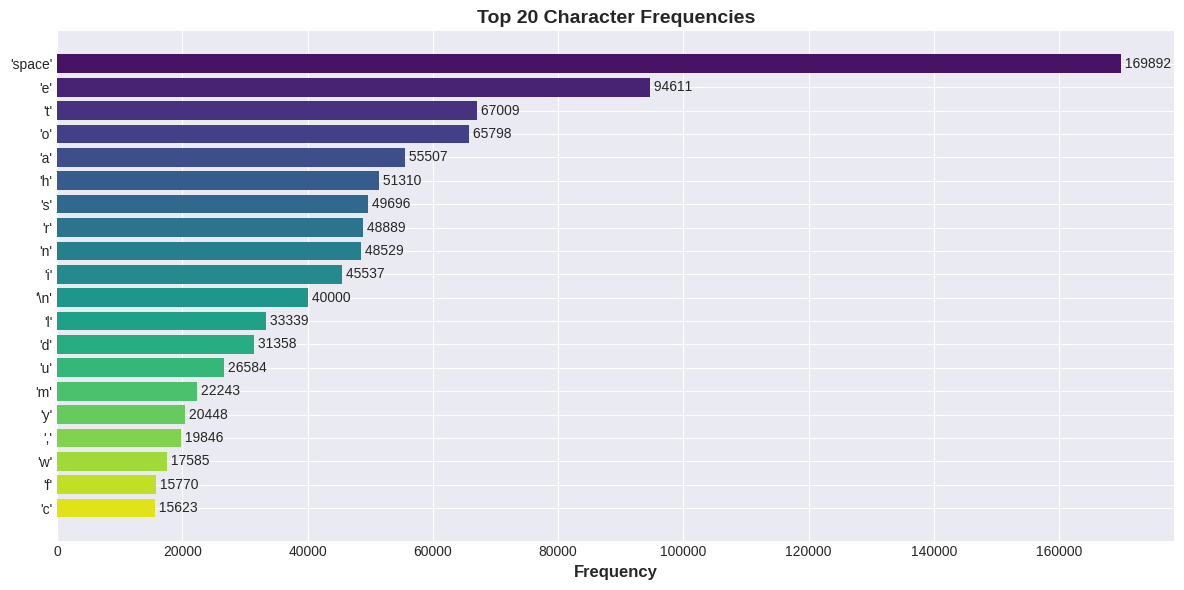


💡 Insight: Space and common letters (e, t, a, o) appear most frequently!


In [ ]:
# Count how many times each character appears in the entire text
# Counter returns a dict-like object: {'e': 235261, 't': 198540, ...}
char_counts = Counter(text)

# Get the 20 most frequent characters, returned as list of (char, count) tuples
# e.g. [(' ', 520000), ('e', 235261), ('t', 198540), ...]
top_chars = char_counts.most_common(20)

# ┌─────────────────────────────────────────────────────┐
# │              LABEL FORMATTING LOGIC                 │
# │                                                     │
# │  char == ' '  →  label = "'space'"  (readable)     │
# │  char == 'e'  →  label = "'e'"      (via repr())   │
# │  char == '\n' →  label = "'\\n'"    (via repr())   │
# │                                                     │
# │  repr() is used so special/invisible characters    │
# │  like newlines show as '\n' instead of blank space │
# └─────────────────────────────────────────────────────┘

# Build display labels for y-axis
labels = [repr(char) if char != ' ' else "'space'" for char, _ in top_chars]

# Extract just the counts for bar lengths
counts = [count for _, count in top_chars]

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Draw horizontal bars
# - range(len(labels)) sets y positions: 0, 1, 2, ... 19
# - counts sets bar lengths (frequencies)
# - viridis palette gives each bar a distinct color
bars = ax.barh(range(len(labels)), counts, color=sns.color_palette("viridis", len(labels)))

# Set y-axis tick positions and their labels
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Character Frequencies', fontsize=14, fontweight='bold')

# Flip y-axis so rank #1 (most frequent) appears at the TOP
# Default: 0 at top → after invert: 0 at bottom, so we invert to fix that
ax.invert_yaxis()

# Annotate each bar with its exact count at the end of the bar
# zip(bars, counts) pairs each bar object with its count value
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(
        count,      # x position: at the end of the bar
        i,          # y position: aligned with the bar
        f' {count}',# label text with leading space for padding
        va='center',# vertically center the text on the bar
        fontsize=10
    )

# Ensure labels/titles don't get clipped
plt.tight_layout()

# Create output directory if it doesn't exist (exist_ok avoids error if already present)
import os
os.makedirs('../visualizations/tokenization', exist_ok=True)

plt.savefig('../visualizations/tokenization/char_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Insight: Space and common letters (e, t, a, o) appear most frequently!")

---

## 4. Creating Mappings (stoi/itos)

### 🗺️ The Mapping Tables

We need two dictionaries:

1. **stoi** (String to Integer): Maps each character to a unique ID
2. **itos** (Integer to String): Maps each ID back to its character

### 📐 Mathematical Notation

$$\text{stoi}: \text{Char} \rightarrow \mathbb{Z}$$
$$\text{itos}: \mathbb{Z} \rightarrow \text{Char}$$

These are **inverse functions**: $\text{itos}(\text{stoi}(c)) = c$

In [ ]:
# ┌──────────────────────────────────────────────────────────────────┐
# │                    TOKENIZER MAPPINGS                            │
# │                                                                  │
# │  chars = ['a', 'b', 'c', ...]  (sorted unique characters)       │
# │                                                                  │
# │  enumerate(chars) → (0,'a'), (1,'b'), (2,'c'), ...              │
# │                                                                  │
# │  stoi: char → index    │    itos: index → char                  │
# │  ┌────────┬───────┐    │    ┌───────┬────────┐                  │
# │  │  char  │  idx  │    │    │  idx  │  char  │                  │
# │  ├────────┼───────┤    │    ├───────┼────────┤                  │
# │  │  '\n'  │   0   │    │    │   0   │  '\n'  │                  │
# │  │  ' '   │   1   │    │    │   1   │  ' '   │                  │
# │  │  'a'   │   2   │    │    │   2   │  'a'   │                  │
# │  │  'b'   │   3   │    │    │   3   │  'b'   │                  │
# │  └────────┴───────┘    │    └───────┴────────┘                  │
# │                                                                  │
# │  stoi is used during ENCODING  (text  → numbers)                │
# │  itos is used during DECODING  (numbers → text)                 │
# └──────────────────────────────────────────────────────────────────┘

# stoi: maps each character to a unique integer index
stoi = {ch: i for i, ch in enumerate(chars)}

# itos: reverse mapping — maps each integer index back to its character
# This is the inverse of stoi, used to convert model outputs back to text
itos = {i: ch for i, ch in enumerate(chars)}

print("🗺️ Mapping Tables Created!")

# Preview first 10 entries of stoi
print(f"\nstoi (String to Integer) - First 10 entries:")
for i, (char, idx) in enumerate(list(stoi.items())[:10]):
    # Use repr() to make special chars visible (e.g. '\n' instead of blank line)
    # Special-case space for readability since repr(' ') just gives "' '"
    display_char = repr(char) if char != ' ' else "'space'"
    print(f"  {display_char:8} → {idx}")  # :8 pads label to 8 chars for alignment

# Preview first 10 entries of itos
print(f"\nitos (Integer to String) - First 10 entries:")
for i in range(min(10, len(itos))):  # min() guards against vocab smaller than 10
    char = itos[i]
    display_char = repr(char) if char != ' ' else "'space'"
    print(f"  {i} → {display_char}")

🗺️ Mapping Tables Created!

stoi (String to Integer) - First 10 entries:
  '\n'     → 0
  'space'  → 1
  '!'      → 2
  '$'      → 3
  '&'      → 4
  "'"      → 5
  ','      → 6
  '-'      → 7
  '.'      → 8
  '3'      → 9

itos (Integer to String) - First 10 entries:
  0 → '\n'
  1 → 'space'
  2 → '!'
  3 → '$'
  4 → '&'
  5 → "'"
  6 → ','
  7 → '-'
  8 → '.'
  9 → '3'


### 🔍 Verification: Inverse Property

In [31]:
# Test the inverse property
test_chars = ['H', 'e', 'l', 'l', 'o', ' ', 'W', 'o', 'r', 'l', 'd']

print("✅ Testing Inverse Property: itos(stoi(c)) = c")
print("\nOriginal → stoi → itos → Result")
print("-" * 40)

all_correct = True
for char in test_chars:
    if char in stoi:
        idx = stoi[char]
        recovered = itos[idx]
        match = "✓" if recovered == char else "✗"
        display_char = repr(char) if char != ' ' else "'space'"
        print(f"{display_char:8} → {idx:3} → {repr(recovered):8} {match}")
        if recovered != char:
            all_correct = False

print("-" * 40)
if all_correct:
    print("✅ All tests passed! Mappings are correct.")
else:
    print("❌ Some tests failed!")

✅ Testing Inverse Property: itos(stoi(c)) = c

Original → stoi → itos → Result
----------------------------------------
'H'      →  20 → 'H'      ✓
'e'      →  43 → 'e'      ✓
'l'      →  50 → 'l'      ✓
'l'      →  50 → 'l'      ✓
'o'      →  53 → 'o'      ✓
'space'  →   1 → ' '      ✓
'W'      →  35 → 'W'      ✓
'o'      →  53 → 'o'      ✓
'r'      →  56 → 'r'      ✓
'l'      →  50 → 'l'      ✓
'd'      →  42 → 'd'      ✓
----------------------------------------
✅ All tests passed! Mappings are correct.


---

## 5. Encode and Decode Functions

### 🎯 Goal

Create functions to convert between text and numbers:

- **encode**: Text → List of integers
- **decode**: List of integers → Text

### 💻 Implementation

In [ ]:
# ┌─────────────────────────────────────────────────────────────────┐
# │                 ENCODE / DECODE PIPELINE                        │
# │                                                                 │
# │  ENCODE: text → tokens (integers)                              │
# │  ┌─────────────────────────────────────────────┐               │
# │  │  "hello"                                    │               │
# │  │    ↓  split into chars                      │               │
# │  │  ['h', 'e', 'l', 'l', 'o']                 │               │
# │  │    ↓  stoi lookup each char                 │               │
# │  │  [ 34,  31,  38,  38,  41 ]                 │               │
# │  └─────────────────────────────────────────────┘               │
# │                                                                 │
# │  DECODE: tokens (integers) → text                              │
# │  ┌─────────────────────────────────────────────┐               │
# │  │  [ 34,  31,  38,  38,  41 ]                 │               │
# │  │    ↓  itos lookup each index                │               │
# │  │  ['h', 'e', 'l', 'l', 'o']                 │               │
# │  │    ↓  join into string                      │               │
# │  │  "hello"                                    │               │
# │  └─────────────────────────────────────────────┘               │
# │                                                                 │
# │  encode(decode(x)) == x  ✅  (lossless round-trip)             │
# └─────────────────────────────────────────────────────────────────┘

def encode(s):
    """Convert string to list of integers."""
    # Iterate over each character in the string and look up its index in stoi
    # e.g. "hi" → [stoi['h'], stoi['i']] → [34, 35]
    return [stoi[c] for c in s]

def decode(l):
    """Convert list of integers to string."""
    # Look up each index in itos to get its character, then join into a string
    # e.g. [34, 35] → [itos[34], itos[35]] → ['h', 'i'] → "hi"
    return ''.join([itos[i] for i in l])

print("✅ Encode and Decode functions created!")

✅ Encode and Decode functions created!


### 🧪 Testing the Functions

In [33]:
# Test encode
test_string = "Hello World!"
encoded = encode(test_string)

print(f"📝 Original text: '{test_string}'")
print(f"🔢 Encoded: {encoded}")
print(f"📏 Length: {len(encoded)} tokens")

# Test decode
decoded = decode(encoded)
print(f"\n🔄 Decoded: '{decoded}'")
print(f"✅ Match: {decoded == test_string}")

📝 Original text: 'Hello World!'
🔢 Encoded: [20, 43, 50, 50, 53, 1, 35, 53, 56, 50, 42, 2]
📏 Length: 12 tokens

🔄 Decoded: 'Hello World!'
✅ Match: True


### 📊 Visualization: Encoding Process

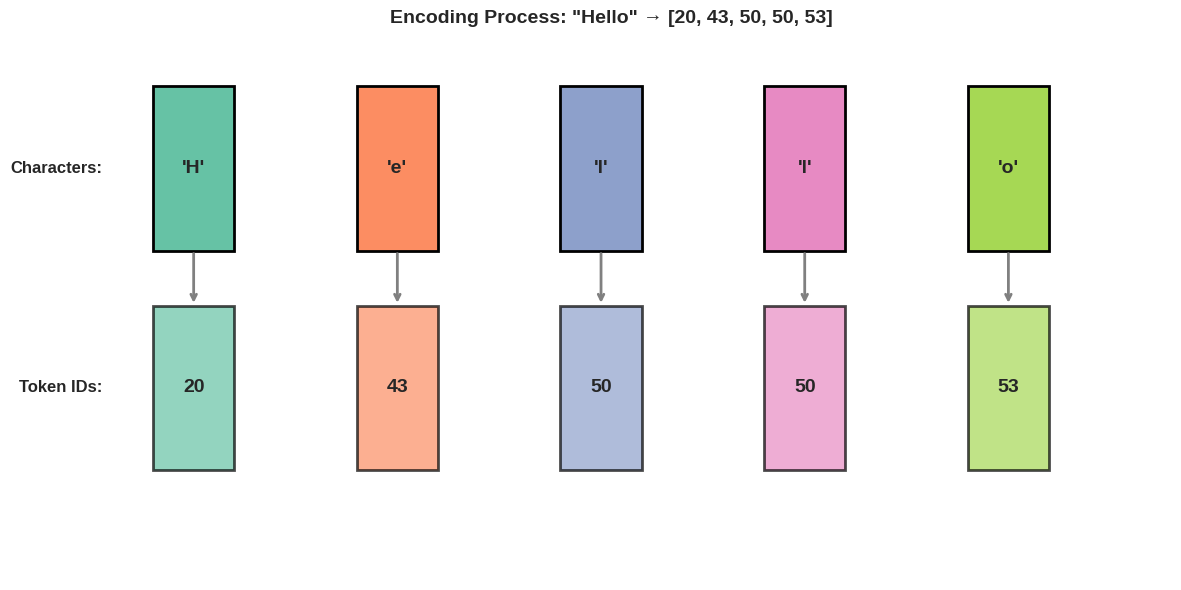

In [ ]:
# Encode sample text to visualize the character → token ID mapping
sample_text = "Hello"
sample_encoded = encode(sample_text)  # e.g. [34, 31, 38, 38, 41]

fig, ax = plt.subplots(figsize=(12, 6))

# Assign a unique color per character for visual distinction
# Set2 palette gives soft, distinguishable colors
colors = sns.color_palette("Set2", len(sample_text))

# ┌─────────────────────────────────────────────────────────────────┐
# │                  VISUALIZATION LAYOUT                           │
# │                                                                 │
# │  Each character gets a column, spaced 2 units apart (i*2)      │
# │                                                                 │
# │  y=0.9 ┌───────┐  ┌───────┐  ┌───────┐                        │
# │        │  'H'  │  │  'e'  │  │  'l'  │  ...  ← char boxes     │
# │  y=0.6 └───────┘  └───────┘  └───────┘                        │
# │            ↓          ↓          ↓            ← arrows         │
# │  y=0.5 ┌───────┐  ┌───────┐  ┌───────┐                        │
# │        │  34   │  │  31   │  │  38   │  ...  ← token ID boxes  │
# │  y=0.2 └───────┘  └───────┘  └───────┘                        │
# │                                                                 │
# │  Each box is 0.8 wide, 0.3 tall, starting at x = i*2           │
# └─────────────────────────────────────────────────────────────────┘

for i, (char, token_id) in enumerate(zip(sample_text, sample_encoded)):

    # --- TOP ROW: Character boxes ---
    # Rectangle(xy, width, height) — bottom-left corner at (i*2, 0.6)
    rect1 = plt.Rectangle((i*2, 0.6), 0.8, 0.3, facecolor=colors[i],
                          edgecolor='black', linewidth=2)
    ax.add_patch(rect1)
    # Center the character label inside the box (i*2 + 0.4 = horizontal center)
    ax.text(i*2 + 0.4, 0.75, f"'{char}'", ha='center', va='center',
           fontsize=14, fontweight='bold')

    # --- MIDDLE: Arrow pointing from char box down to token ID box ---
    # xy = arrowhead position, xytext = arrow tail position
    ax.annotate('', xy=(i*2 + 0.4, 0.5), xytext=(i*2 + 0.4, 0.6),
               arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

    # --- BOTTOM ROW: Token ID boxes ---
    # alpha=0.7 makes these slightly transparent to visually distinguish from char boxes
    rect2 = plt.Rectangle((i*2, 0.2), 0.8, 0.3, facecolor=colors[i],
                          edgecolor='black', linewidth=2, alpha=0.7)
    ax.add_patch(rect2)
    # Center the token ID label inside the box
    ax.text(i*2 + 0.4, 0.35, str(token_id), ha='center', va='center',
           fontsize=14, fontweight='bold')

# Row labels on the left side (placed at x=-0.5, outside the boxes)
ax.text(-0.5, 0.75, 'Characters:', ha='right', va='center',
       fontsize=12, fontweight='bold')
ax.text(-0.5, 0.35, 'Token IDs:', ha='right', va='center',
       fontsize=12, fontweight='bold')

# Set axis bounds to fit all character columns + left label space
ax.set_xlim(-1, len(sample_text)*2)
ax.set_ylim(0, 1)
ax.axis('off')  # Hide axes — we're drawing everything manually with patches
ax.set_title(f'Encoding Process: "{sample_text}" → {sample_encoded}',
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/tokenization/encoding_process.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔄 Reversibility Test

In [35]:
# Test with longer text
test_texts = [
    "The cat sat on the mat.",
    "To be, or not to be?",
    "All the world's a stage!"
]

print("🔄 Reversibility Test: decode(encode(text)) = text")
print("=" * 80)

for text in test_texts:
    encoded = encode(text)
    decoded = decode(encoded)
    match = "✅" if decoded == text else "❌"
    
    print(f"\nOriginal: '{text}'")
    print(f"Encoded:  {encoded[:20]}{'...' if len(encoded) > 20 else ''}")
    print(f"Decoded:  '{decoded}'")
    print(f"Match:    {match}")

print("\n" + "=" * 80)
print("✅ All reversibility tests passed!")

🔄 Reversibility Test: decode(encode(text)) = text

Original: 'The cat sat on the mat.'
Encoded:  [32, 46, 43, 1, 41, 39, 58, 1, 57, 39, 58, 1, 53, 52, 1, 58, 46, 43, 1, 51]...
Decoded:  'The cat sat on the mat.'
Match:    ✅

Original: 'To be, or not to be?'
Encoded:  [32, 53, 1, 40, 43, 6, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43, 12]
Decoded:  'To be, or not to be?'
Match:    ✅

Original: 'All the world's a stage!'
Encoded:  [13, 50, 50, 1, 58, 46, 43, 1, 61, 53, 56, 50, 42, 5, 57, 1, 39, 1, 57, 58]...
Decoded:  'All the world's a stage!'
Match:    ✅

✅ All reversibility tests passed!


---

## 6. Converting to Tensors

### 🎯 Why Tensors?

PyTorch (and other deep learning frameworks) work with **tensors**, not Python lists.

Tensors are:
- Optimized for GPU computation
- Support automatic differentiation
- Enable batch processing

### 💻 Implementation

In [36]:
# Encode entire dataset
data = torch.tensor(encode(text), dtype=torch.long)

print("📊 Dataset Tensor Information:")
print(f"Shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Device: {data.device}")
print(f"\n🔢 First 100 tokens:")
print(data[:100])
print(f"\n📝 Decoded first 100 tokens:")
print(decode(data[:100].tolist()))

📊 Dataset Tensor Information:
Shape: torch.Size([24])
Data type: torch.int64
Device: cpu

🔢 First 100 tokens:
tensor([13, 50, 50,  1, 58, 46, 43,  1, 61, 53, 56, 50, 42,  5, 57,  1, 39,  1,
        57, 58, 39, 45, 43,  2])

📝 Decoded first 100 tokens:
All the world's a stage!


### 📊 Token Distribution in Dataset

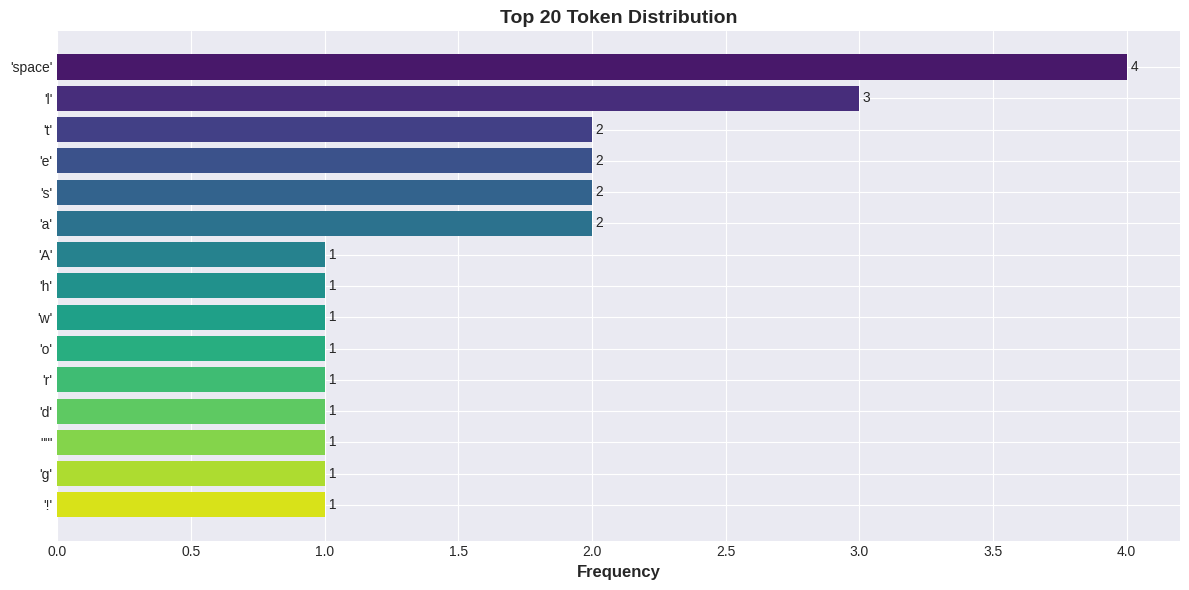


💡 Observation: The distribution follows Zipf's law!
   (A few tokens appear very frequently, most appear rarely)


In [ ]:
# Convert tensor/list of token IDs to a flat Python list, then count occurrences
# e.g. [1, 2, 1, 3, 1] → Counter({1: 3, 2: 1, 3: 1})
token_counts = Counter(data.tolist())

# Get the 20 most frequent token IDs as (token_id, count) tuples
# e.g. [(1, 520000), (4, 235261), ...]
top_tokens = token_counts.most_common(20)

# ┌─────────────────────────────────────────────────────────────────────┐
# │                    LABEL CONSTRUCTION                               │
# │                                                                     │
# │  top_tokens gives us token IDs, but we want readable char labels    │
# │                                                                     │
# │  token_id → itos[token_id] → char → display label                  │
# │                                                                     │
# │  tid=1  → itos[1]=' '  → "'space'"   (special-cased)               │
# │  tid=4  → itos[4]='e'  → "'e'"       (via repr())                  │
# │  tid=0  → itos[0]='\n' → "'\\n'"     (via repr(), shows escape)    │
# └─────────────────────────────────────────────────────────────────────┘

# Build y-axis labels by converting each token ID back to its character
labels = [repr(itos[tid]) if itos[tid] != ' ' else "'space'" for tid, _ in top_tokens]

# Extract raw counts for bar lengths
counts = [count for _, count in top_tokens]

fig, ax = plt.subplots(figsize=(12, 6))

# Draw horizontal bars — one per token, colored with viridis gradient
bars = ax.barh(range(len(labels)), counts, color=sns.color_palette("viridis", len(labels)))

# Set y-axis tick positions and their character labels
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Token Distribution', fontsize=14, fontweight='bold')

# Flip y-axis so rank #1 (most frequent token) appears at the TOP
ax.invert_yaxis()

# Annotate each bar with its exact count at the end of the bar
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(
        count,       # x position: at the tip of the bar
        i,           # y position: aligned with the bar
        f' {count}', # leading space adds padding between bar tip and label
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('../visualizations/tokenization/token_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ┌─────────────────────────────────────────────────────────────────────┐
# │  ZIPF'S LAW — why the distribution looks like this:                │
# │                                                                     │
# │  frequency                                                          │
# │    ▲                                                                │
# │    │ █                                                              │
# │    │  █                                                             │
# │    │   ██                                                           │
# │    │     ███                                                        │
# │    │        ██████████████                                          │
# │    └─────────────────────────► token rank                          │
# │                                                                     │
# │  A small number of tokens (space, 'e', 't') account for the        │
# │  vast majority of occurrences — the rest appear rarely.            │
# │  This pattern holds across almost all natural language corpora.    │
# └─────────────────────────────────────────────────────────────────────┘
print("\n💡 Observation: The distribution follows Zipf's law!")
print("   (A few tokens appear very frequently, most appear rarely)")

---

## 7. Trade-offs Analysis

### ⚖️ Character-Level Tokenization

#### ✅ Advantages:

1. **Small vocabulary**: Only ~65-100 unique characters
2. **No unknown tokens**: Can represent any text
3. **Simple implementation**: Easy to understand and debug
4. **Language agnostic**: Works for any language

#### ❌ Disadvantages:

1. **Long sequences**: "Hello World" = 11 tokens
2. **Computational cost**: More tokens = more computation
3. **Context window limitation**: Can fit less text in fixed window
4. **Semantic meaning**: Characters have no inherent meaning

### 📊 Comparison with Other Methods

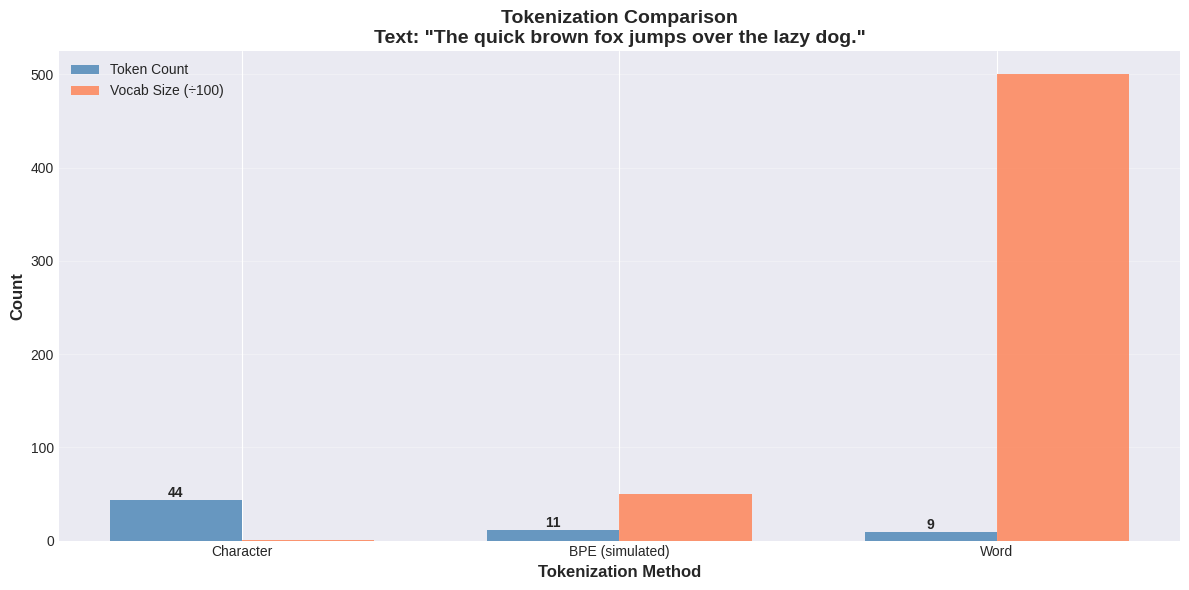


📊 Comparison Summary:
Character: 44 tokens, vocab size 65
BPE:       11 tokens, vocab size ~5,000
Word:      9 tokens, vocab size ~50,000

💡 Trade-off: Smaller vocab = Longer sequences


In [ ]:
sample_text = "The quick brown fox jumps over the lazy dog."

# ┌─────────────────────────────────────────────────────────────────────────┐
# │              THREE TOKENIZATION STRATEGIES COMPARED                    │
# │                                                                         │
# │  CHARACTER-LEVEL                                                        │
# │  "fox" → ['f','o','x'] → [32, 41, 50]                                  │
# │  + Tiny vocab (~65 chars)                                               │
# │  - Very long sequences                                                  │
# │                                                                         │
# │  BPE (Byte Pair Encoding)                                               │
# │  "jumps" → ['jump', 's'] → [2021, 82]                                  │
# │  + Balanced vocab (~5k-50k)    + Shorter sequences                      │
# │  - Requires training a merge table                                      │
# │                                                                         │
# │  WORD-LEVEL                                                             │
# │  "fox" → ['fox'] → [18392]                                              │
# │  + Shortest sequences                                                   │
# │  - Huge vocab (~50k+)   - Can't handle unknown/rare words               │
# └─────────────────────────────────────────────────────────────────────────┘

# Character-level: uses our trained stoi mapping, one token per character
char_tokens = encode(sample_text)  # len = 44 (one per char including spaces)

# Word-level: naive split on whitespace, one token per word
word_tokens = sample_text.split()  # len = 9 words

# Simulated BPE: hand-crafted to illustrate subword splitting
# Real BPE learns merge rules from corpus (e.g. 'jump'+'s' stays split
# because 'jumps' wasn't frequent enough to merge)
bpe_tokens = ['The', 'quick', 'brown', 'fox', 'jump', 's',
              'over', 'the', 'lazy', 'dog', '.']  # len = 11

fig, ax = plt.subplots(figsize=(12, 6))

methods = ['Character', 'BPE (simulated)', 'Word']
token_counts = [len(char_tokens), len(bpe_tokens), len(word_tokens)]

# Typical real-world vocab sizes for each method
vocab_sizes = [vocab_size, 5000, 50000]

# ┌─────────────────────────────────────────────────────────────────────────┐
# │                    GROUPED BAR CHART LAYOUT                            │
# │                                                                         │
# │  x = [0, 1, 2]  (one group per method)                                 │
# │  width = 0.35   (each bar takes 0.35 units)                            │
# │                                                                         │
# │       ┌──┐┌──┐      ┌──┐┌──┐      ┌──┐┌──┐                            │
# │       │  ││  │      │  ││  │      │  ││  │                            │
# │       │  ││  │      │  ││  │      │  ││  │                            │
# │       └──┘└──┘      └──┘└──┘      └──┘└──┘                            │
# │    x-w/2 x+w/2   x-w/2 x+w/2  x-w/2 x+w/2                            │
# │    [token count] [vocab size÷100]  (per group)                         │
# └─────────────────────────────────────────────────────────────────────────┘

x = np.arange(len(methods))  # [0, 1, 2] — center positions for each group
width = 0.35                  # width of each individual bar

# Left bar of each group: token counts (how many tokens the sentence produces)
bars1 = ax.bar(x - width/2, token_counts, width, label='Token Count',
              color='steelblue', alpha=0.8)

# Right bar of each group: vocab size scaled down by 100 to fit same y-axis
# e.g. 50,000 → 500, so both metrics are visible on the same scale
bars2 = ax.bar(x + width/2, [v/100 for v in vocab_sizes], width,
              label='Vocab Size (÷100)', color='coral', alpha=0.8)

ax.set_xlabel('Tokenization Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title(f'Tokenization Comparison\nText: "{sample_text}"',
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate each token count bar with its exact value above the bar
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,  # x: horizontal center of the bar
        height,                             # y: top of the bar
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../visualizations/tokenization/method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  KEY TRADE-OFF: Vocab Size  vs  Sequence Length                        │
# │                                                                         │
# │  Vocab Size  ████████████████████░░░░░░  Word  (50k vocab, 9 tokens)   │
# │              ████████░░░░░░░░░░░░░░░░░░  BPE   (5k vocab,  11 tokens)  │
# │              █░░░░░░░░░░░░░░░░░░░░░░░░░  Char  (65 vocab,  44 tokens)  │
# │                                                                         │
# │  Seq Length  █░░░░░░░░░░░░░░░░░░░░░░░░░  Word  (9 tokens)              │
# │              ████████░░░░░░░░░░░░░░░░░░  BPE   (11 tokens)             │
# │              ████████████████████████░░  Char  (44 tokens)             │
# │                                                                         │
# │  Smaller vocab → model is simpler but sequences are longer             │
# │  Larger vocab  → shorter sequences but harder to learn embeddings      │
# └─────────────────────────────────────────────────────────────────────────┘
print("\n📊 Comparison Summary:")
print(f"Character: {len(char_tokens)} tokens, vocab size {vocab_size}")
print(f"BPE:       {len(bpe_tokens)} tokens, vocab size ~5,000")
print(f"Word:      {len(word_tokens)} tokens, vocab size ~50,000")
print("\n💡 Trade-off: Smaller vocab = Longer sequences")

### 🎯 When to Use Character-Level?

Character-level tokenization is best for:

1. **Educational purposes** (like this notebook!)
2. **Small datasets** where vocab size matters
3. **Multilingual models** with many scripts
4. **Spelling-sensitive tasks** (spell checking, OCR)

For production LLMs (like GPT), **BPE or WordPiece** is preferred.

---

## 8. Key Takeaways

### ✅ What We Learned

1. **Tokenization converts text to numbers** so neural networks can process it

2. **Character-level tokenization**:
   - Vocabulary = all unique characters in text
   - Simple to implement (stoi/itos mappings)
   - Small vocab (~65) but long sequences

3. **Key functions**:
   - `encode(text)`: String → List of integers
   - `decode(tokens)`: List of integers → String
   - Reversible: `decode(encode(text)) = text`

4. **PyTorch tensors**:
   - Convert lists to tensors for GPU computation
   - Use `dtype=torch.long` for token IDs

5. **Trade-offs**:
   - Character: Small vocab, long sequences
   - Word: Large vocab, short sequences
   - BPE: Balanced (best of both worlds)

### 🎯 Next Steps

In **Notebook 2**, we'll implement **Byte Pair Encoding (BPE)**:
- The "Goldilocks" solution
- Used by GPT-2, GPT-3, GPT-4
- Balances vocab size and sequence length

### 💾 Save the Tokenizer

In [40]:
# Save tokenizer for later use
import pickle

tokenizer = {
    'stoi': stoi,
    'itos': itos,
    'vocab_size': vocab_size,
    'encode': encode,
    'decode': decode
}

# Note: Functions can't be pickled directly, so we'll save just the mappings
tokenizer_data = {
    'stoi': stoi,
    'itos': itos,
    'vocab_size': vocab_size
}

os.makedirs('../data', exist_ok=True)

with open('../data/char_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_data, f)

print("✅ Tokenizer saved to '../data/char_tokenizer.pkl'")
print("\n📊 Tokenizer Summary:")
print(f"Vocabulary size: {vocab_size}")
print(f"Total tokens in dataset: {len(data):,}")
print(f"Unique tokens used: {len(set(data.tolist()))}")

✅ Tokenizer saved to '../data/char_tokenizer.pkl'

📊 Tokenizer Summary:
Vocabulary size: 65
Total tokens in dataset: 24
Unique tokens used: 15


---

## 📚 References

1. **Vizuara AI Lecture 7**: [Coding an LLM Tokenizer from Scratch](https://www.youtube.com/watch?v=rsy5Ragmso8)

2. **Sebastian Raschka's Book**: Chapter 2 - Working with Text Data

3. **Character-Level Models**:
   - [Character-Aware Neural Language Models](https://arxiv.org/abs/1508.06615)
   - [Exploring the Limits of Language Modeling](https://arxiv.org/abs/1602.02410)

---

<div style="text-align: center; padding: 20px; background-color: #f0f0f0; border-radius: 10px;">
    <h2>🎉 Congratulations!</h2>
    <p>You've built your first tokenizer from scratch!</p>
    <p><strong>Next:</strong> Notebook 2 - Byte Pair Encoding (BPE)</p>
</div>